In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual para gráficos mais elegantes no portfólio
sns.set_theme(style="whitegrid", palette="muted")

# 1. Carregando os dados
#df = pd.read_csv(r'H:\Universidade dos dados\projetos\mobile_device\user_behavior_dataset.csv')

df = pd.read_csv(r'C:\Users\gustavos\Documents\projetos\mobile_device\user_behavior_dataset.csv')


## 1 Distribuição Gênero x Sistema Operacional

Colunas: ['User ID', 'Device Model', 'Operating System', 'App Usage Time (min/day)', 'Screen On Time (hours/day)', 'Battery Drain (mAh/day)', 'Number of Apps Installed', 'Data Usage (MB/day)', 'Age', 'Gender', 'User Behavior Class']

Distribuição de Sistema Operacional (%):
Operating System
Android    79.142857
iOS        20.857143
Name: proportion, dtype: float64

Distribuição de Gênero (%):
Gender
Male      52.0
Female    48.0
Name: proportion, dtype: float64


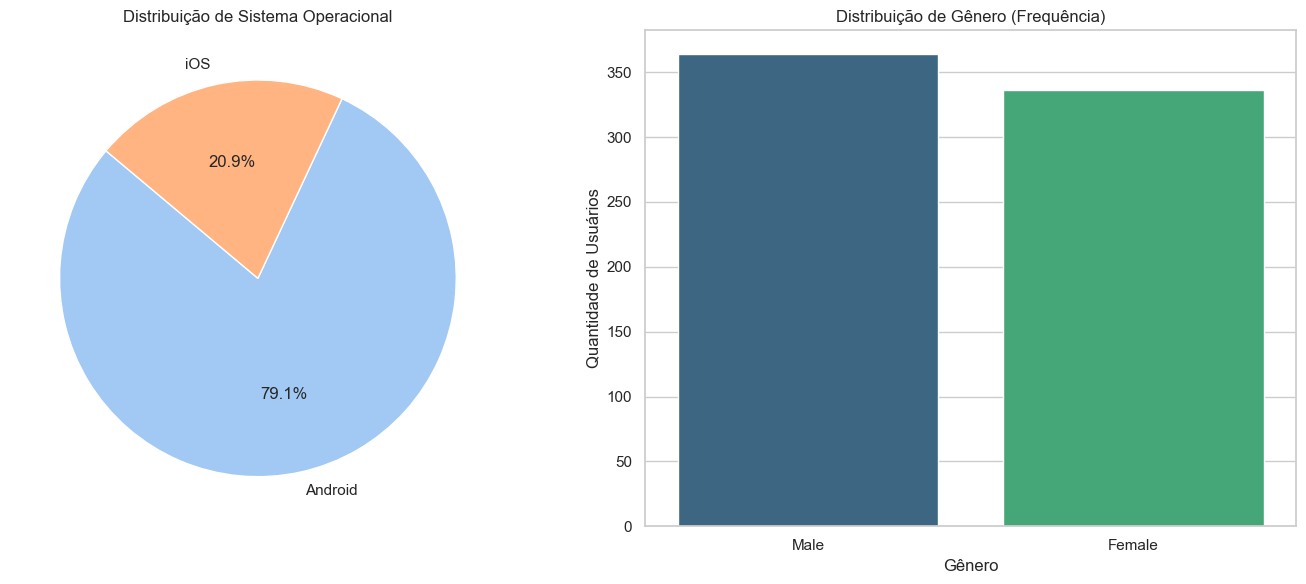

In [4]:
# Verificar as colunas disponíveis para garantir os nomes corretos
print("Colunas:", df.columns.tolist())

# Calcular a distribuição de Sistema Operacional
os_dist = df['Operating System'].value_counts(normalize=True) * 100

# Calcular a distribuição de Gênero
gender_dist = df['Gender'].value_counts(normalize=True) * 100

print("\nDistribuição de Sistema Operacional (%):")
print(os_dist)

print("\nDistribuição de Gênero (%):")
print(gender_dist)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo
sns.set_theme(style="whitegrid")

# Carregar o dataset
df = pd.read_csv('user_behavior_dataset.csv')

# Criar uma figura com dois subplots (Lado a lado)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Distribuição de Sistema Operacional
os_counts = df['Operating System'].value_counts()
axes[0].pie(os_counts, labels=os_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
axes[0].set_title('Distribuição de Sistema Operacional')

# Gráfico 2: Distribuição de Gênero
sns.countplot(data=df, x='Gender', ax=axes[1], palette='viridis', hue='Gender', legend=False)
axes[1].set_title('Distribuição de Gênero (Frequência)')
axes[1].set_ylabel('Quantidade de Usuários')
axes[1].set_xlabel('Gênero')

plt.tight_layout()
plt.savefig('distribuicao_usuario.png')
plt.show()

## 2. Análise para variáveis numéricas 

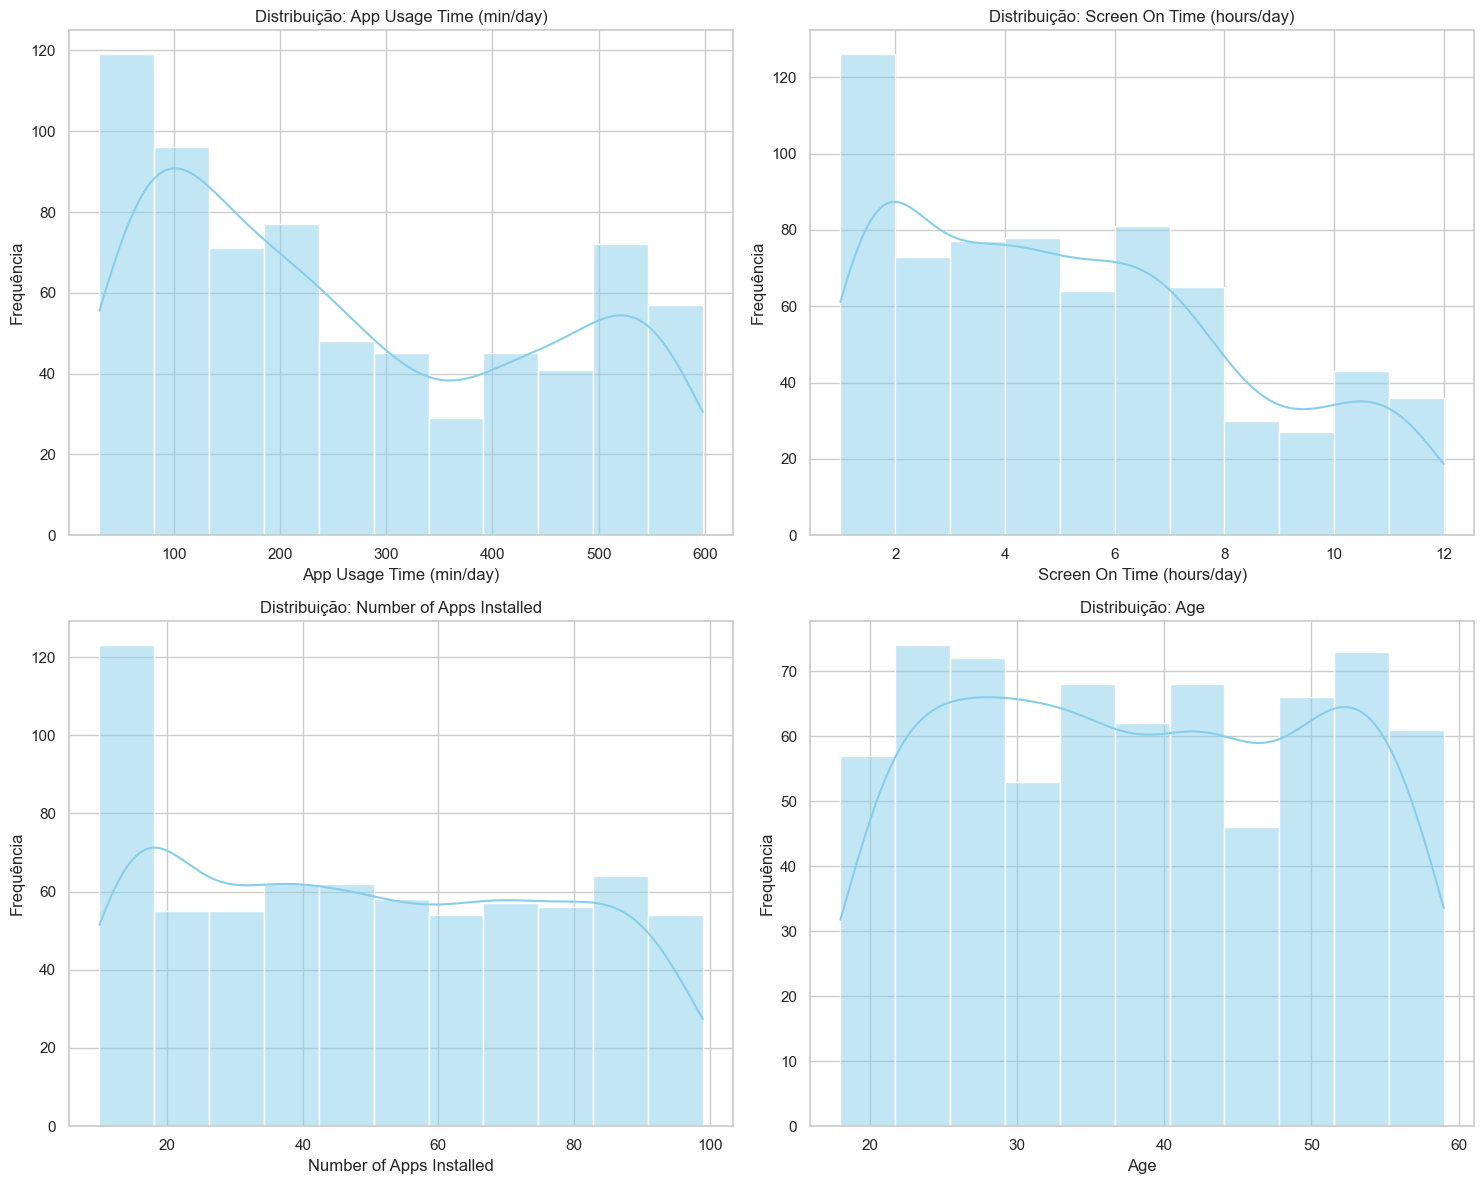

                                  mean         std   min    50%    max
App Usage Time (min/day)    271.128571  177.199484  30.0  227.5  598.0
Screen On Time (hours/day)    5.272714    3.068584   1.0    4.9   12.0
Number of Apps Installed     50.681429   26.943324  10.0   49.0   99.0
Age                          38.482857   12.012916  18.0   38.0   59.0


In [5]:
# Configuração de estilo
sns.set_theme(style="whitegrid")

# Carregar o dataset
df = pd.read_csv('user_behavior_dataset.csv')

# Colunas numéricas solicitadas
cols = ['App Usage Time (min/day)', 'Screen On Time (hours/day)', 'Number of Apps Installed', 'Age']

# Gerar estatísticas descritivas
desc_stats = df[cols].describe().transpose()

# Criar visualizações (Histogramas com KDE)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribuição: {col}')
    axes[i].set_ylabel('Frequência')

plt.tight_layout()
plt.savefig('analise_univariada.png')
plt.show()

print(desc_stats[['mean', 'std', 'min', '50%', 'max']])

## 3. Número de Observações 

C:\Users\gustavos\AppData\Local\Temp\ipykernel_28792\858109274.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  behavior_plot = sns.countplot(data=df, x='User Behavior Class', palette='viridis')


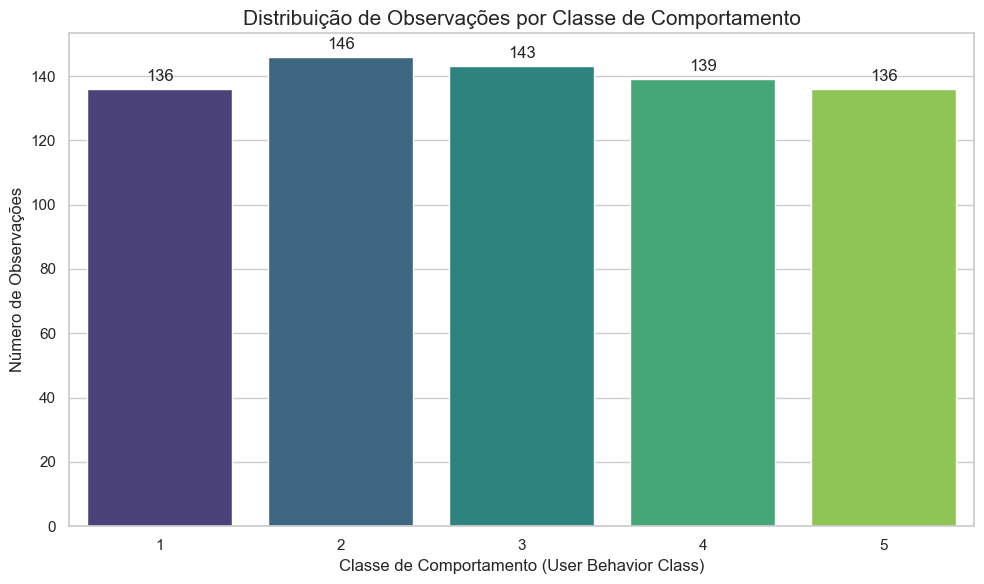

In [6]:
# Configuração de estilo
sns.set_theme(style="whitegrid")

# Criar o gráfico de barras para as classes de comportamento
plt.figure(figsize=(10, 6))
behavior_plot = sns.countplot(data=df, x='User Behavior Class', palette='viridis')

# Adicionar títulos e rótulos
plt.title('Distribuição de Observações por Classe de Comportamento', fontsize=15)
plt.xlabel('Classe de Comportamento (User Behavior Class)', fontsize=12)
plt.ylabel('Número de Observações', fontsize=12)

# Adicionar os valores exatos em cima das barras para clareza
for p in behavior_plot.patches:
    behavior_plot.annotate(f'{int(p.get_height())}', 
                           (p.get_x() + p.get_width() / 2., p.get_height()), 
                           ha = 'center', va = 'center', 
                           xytext = (0, 9), 
                           textcoords = 'offset points')

plt.tight_layout()
plt.savefig('barras_comportamento.png')
plt.show()

# 4. Perfil de uso de bateria 

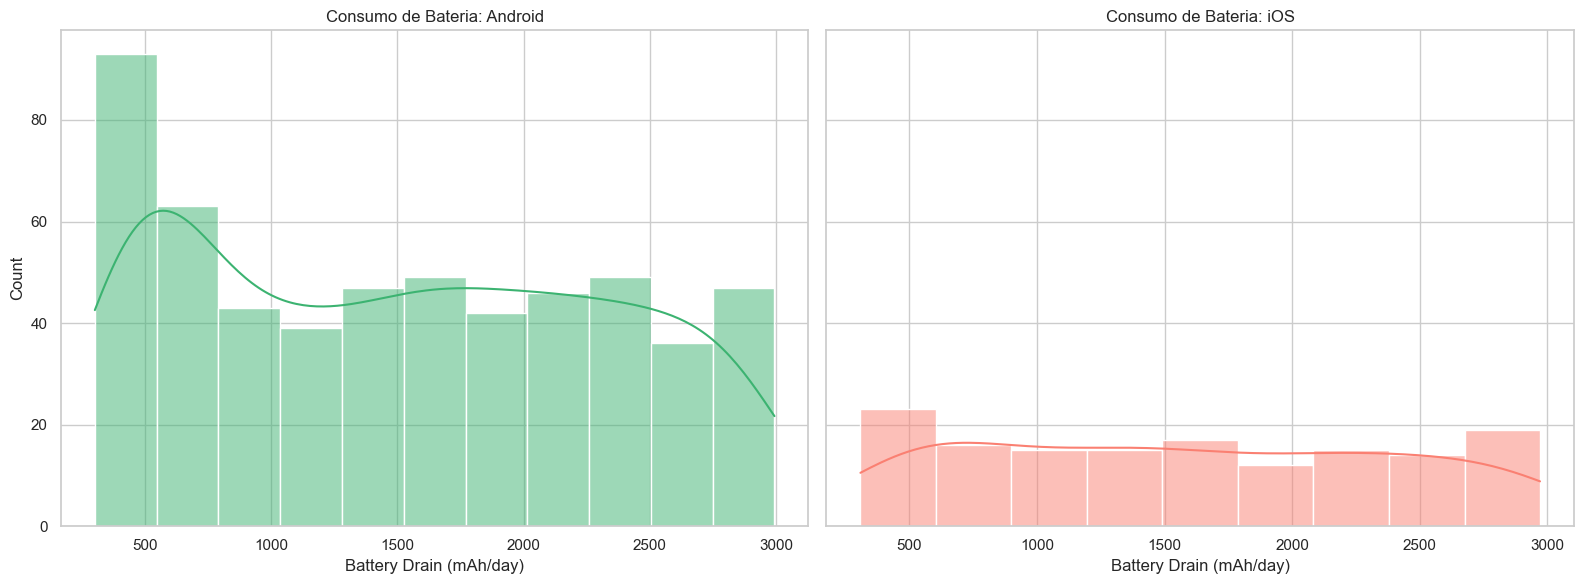

In [7]:
# Criar a figura para os histogramas lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Histograma para Android
sns.histplot(data=df[df['Operating System'] == 'Android'], x='Battery Drain (mAh/day)', 
             kde=True, ax=axes[0], color='mediumseagreen')
axes[0].set_title('Consumo de Bateria: Android')

# Histograma para iOS
sns.histplot(data=df[df['Operating System'] == 'iOS'], x='Battery Drain (mAh/day)', 
             kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Consumo de Bateria: iOS')

plt.tight_layout()
plt.show()

## 5. Relação entre tempo de tela ligada e consumo de bateria 

<Figure size 1200x800 with 0 Axes>

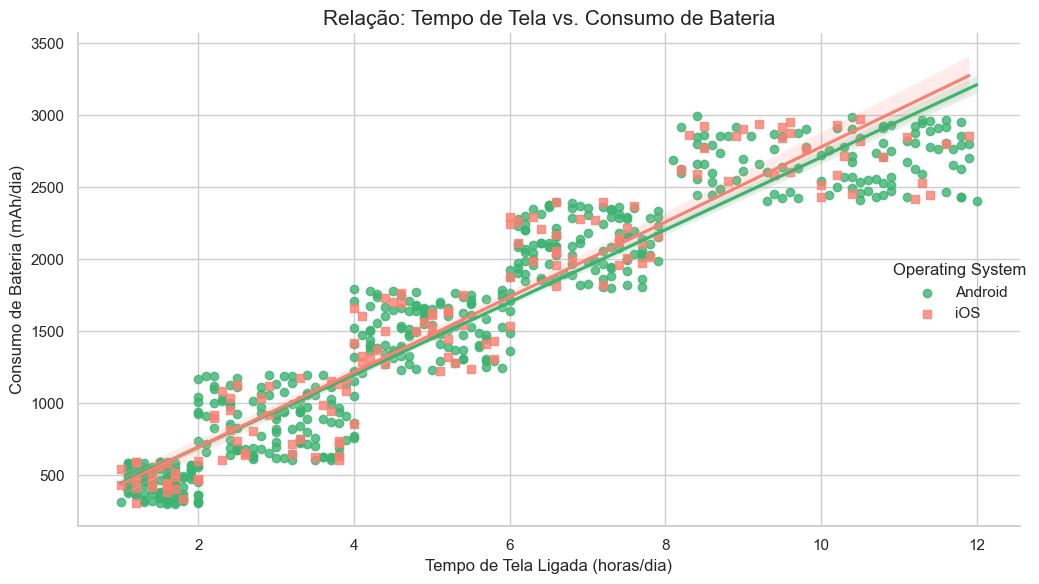

Correlação de Pearson (Android): 0.9502
Correlação de Pearson (iOS): 0.9448


In [10]:
# Configuração de estilo
sns.set_theme(style="whitegrid")

# Criar o gráfico de dispersão com linha de regressão
plt.figure(figsize=(12, 8))
scatter = sns.lmplot(data=df, x='Screen On Time (hours/day)', y='Battery Drain (mAh/day)', 
                     hue='Operating System', palette={'Android': 'mediumseagreen', 'iOS': 'salmon'},
                     markers=["o", "s"], facet_kws={'legend_out': True}, height=6, aspect=1.5)

# Títulos e rótulos
plt.title('Relação: Tempo de Tela vs. Consumo de Bateria', fontsize=15)
plt.xlabel('Tempo de Tela Ligada (horas/dia)', fontsize=12)
plt.ylabel('Consumo de Bateria (mAh/dia)', fontsize=12)

plt.tight_layout()
plt.savefig('relacao_tela_bateria.png')
plt.show()

# Calcular a correlação de Pearson para cada sistema
corr_android = df[df['Operating System'] == 'Android'][['Screen On Time (hours/day)', 'Battery Drain (mAh/day)']].corr().iloc[0,1]
corr_ios = df[df['Operating System'] == 'iOS'][['Screen On Time (hours/day)', 'Battery Drain (mAh/day)']].corr().iloc[0,1]

print(f"Correlação de Pearson (Android): {corr_android:.4f}")
print(f"Correlação de Pearson (iOS): {corr_ios:.4f}")

##Comportamento: Em ambos os casos, conforme o tempo de tela aumenta, o consumo de bateria sobe de forma quase linear.

## 6. Distribuição de aplicativos instalados por usuários

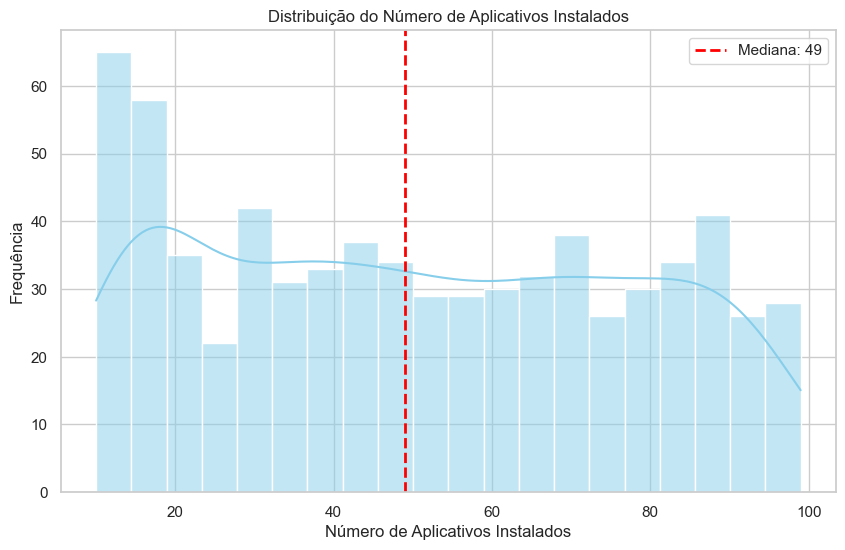

In [12]:
# Calcular a mediana
median_apps = df['Number of Apps Installed'].median()

# Criar o histograma
plt.figure(figsize=(10, 6))
sns.histplot(df['Number of Apps Installed'], kde=True, color='skyblue', bins=20)

# Linha vertical da mediana
plt.axvline(median_apps, color='red', linestyle='--', linewidth=2, label=f'Mediana: {median_apps:.0f}')

plt.title('Distribuição do Número de Aplicativos Instalados')
plt.xlabel('Número de Aplicativos Instalados')
plt.ylabel('Frequência')
plt.legend()
plt.show()



## 7. PERFIL DE USO COM BASE NO GÊNERO

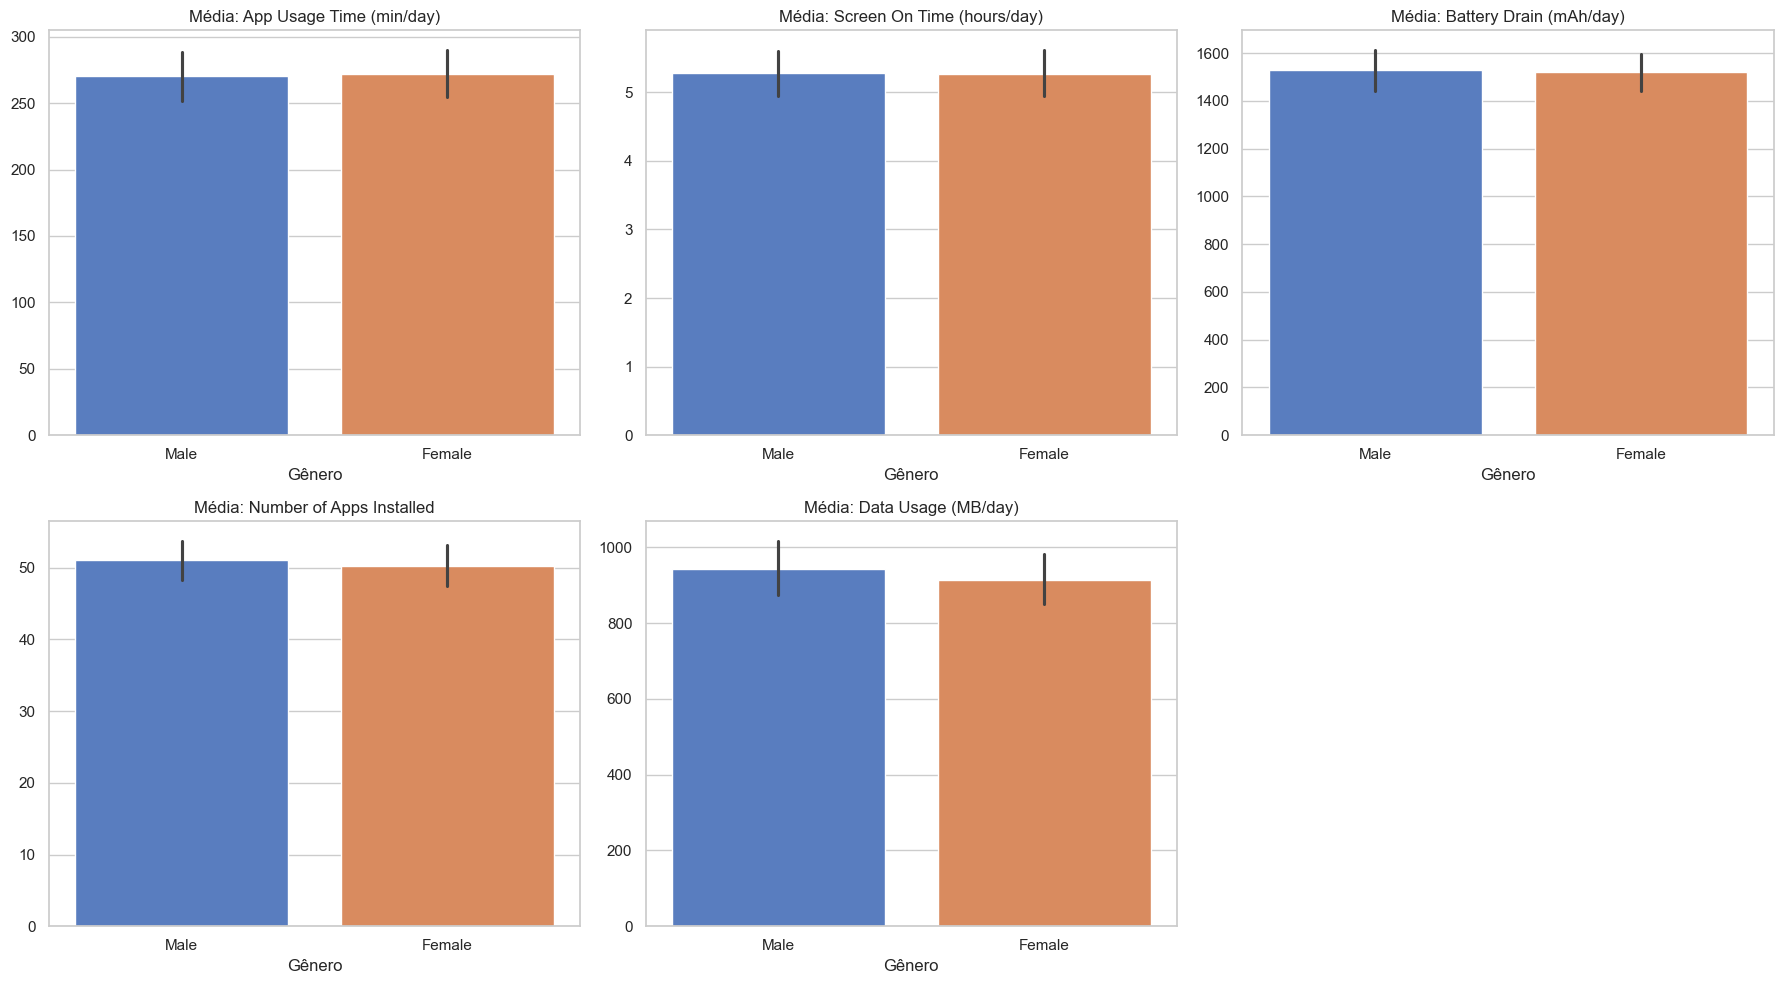

Médias por Gênero:
        App Usage Time (min/day)  Screen On Time (hours/day)  \
Gender                                                         
Female                271.967262                    5.261310   
Male                  270.354396                    5.283242   

        Battery Drain (mAh/day)  Number of Apps Installed  Data Usage (MB/day)  
Gender                                                                          
Female              1519.815476                 50.226190           914.321429  
Male                1530.090659                 51.101648           943.978022  


In [14]:
# Variáveis para análise por gênero
numeric_cols = ['App Usage Time (min/day)', 'Screen On Time (hours/day)', 
                'Battery Drain (mAh/day)', 'Number of Apps Installed', 'Data Usage (MB/day)']

# Agrupar por gênero e calcular a média
gender_analysis = df.groupby('Gender')[numeric_cols].mean()

# Criar visualizações comparativas
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.barplot(data=df, x='Gender', y=col, ax=axes[i], palette='muted', hue='Gender', legend=False)
    axes[i].set_title(f'Média: {col}')
    axes[i].set_ylabel('')
    axes[i].set_xlabel('Gênero')

# Remover o último subplot vazio
fig.delaxes(axes[-1])

plt.tight_layout()
plt.savefig('analise_genero.png')
plt.show()

print("Médias por Gênero:")
print(gender_analysis)

In [16]:
# Definir as colunas numéricas de interesse
cols = [
    'App Usage Time (min/day)', 
    'Screen On Time (hours/day)', 
    'Battery Drain (mAh/day)', 
    'Number of Apps Installed', 
    'Data Usage (MB/day)'
]

# Agrupar por gênero e calcular a média, arredondando para 2 casas decimais
tabela_genero = df.groupby('Gender')[cols].mean().round(2)

# Exibir a tabela
print(tabela_genero)

        App Usage Time (min/day)  Screen On Time (hours/day)  \
Gender                                                         
Female                    271.97                        5.26   
Male                      270.35                        5.28   

        Battery Drain (mAh/day)  Number of Apps Installed  Data Usage (MB/day)  
Gender                                                                          
Female                  1519.82                     50.23               914.32  
Male                    1530.09                     51.10               943.98  


## 8. Correlação entre idade dos usuários e uso de aplicativos 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User ID                     700 non-null    int64  
 1   Device Model                700 non-null    object 
 2   Operating System            700 non-null    object 
 3   App Usage Time (min/day)    700 non-null    int64  
 4   Screen On Time (hours/day)  700 non-null    float64
 5   Battery Drain (mAh/day)     700 non-null    int64  
 6   Number of Apps Installed    700 non-null    int64  
 7   Data Usage (MB/day)         700 non-null    int64  
 8   Age                         700 non-null    int64  
 9   Gender                      700 non-null    object 
 10  User Behavior Class         700 non-null    int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 60.3+ KB
None
   User ID    Device Model Operating System  App Usage Time (min/day)  \
0        1  G

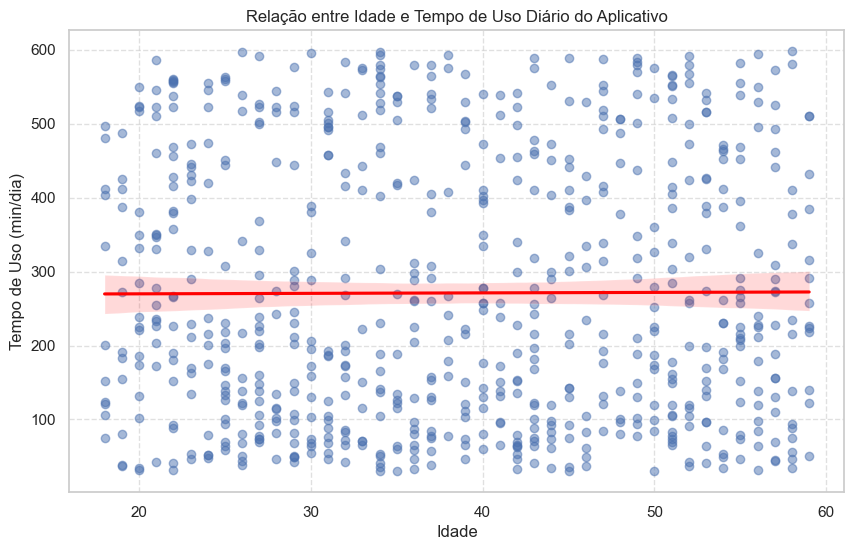

In [17]:
# Exibindo as primeiras linhas e informações básicas para entender as colunas
print(df.info())
print(df.head())

# Calculando a correlação entre Idade (Age) e Tempo de Uso (App Usage Time (min/day))
# Nota: Os nomes das colunas podem variar, vou ajustar se necessário após o print(df.info())
correlation = df['Age'].corr(df['App Usage Time (min/day)'])
print(f"\nCorrelação de Pearson entre Idade e Tempo de Uso: {correlation:.4f}")

# Criando o gráfico de dispersão com linha de regressão
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Age', y='App Usage Time (min/day)', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Relação entre Idade e Tempo de Uso Diário do Aplicativo')
plt.xlabel('Idade')
plt.ylabel('Tempo de Uso (min/dia)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('relacao_idade_uso.png')
plt.show()

In [18]:
import pandas as pd

# Carregando o dataset
df = pd.read_csv('user_behavior_dataset.csv')

# Criando as faixas etárias
bins = [0, 18, 30, 45, 60, 100]
labels = ['Até 18', '19-30', '31-45', '46-60', 'Acima de 60']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

# Calculando a média de tempo de uso por faixa etária
age_group_analysis = df.groupby('Age Group', observed=True)['App Usage Time (min/day)'].agg(['mean', 'count']).reset_index()
age_group_analysis.columns = ['Faixa Etária', 'Média de Tempo (min/dia)', 'Quantidade de Usuários']

print(age_group_analysis)

  Faixa Etária  Média de Tempo (min/dia)  Quantidade de Usuários
0       Até 18                264.272727                      11
1        19-30                265.840580                     207
2        31-45                265.807087                     254
3        46-60                282.188596                     228


## 9 Sistema operacional mais comum entre os usuários 

Distribuição de Sistema Operacional por Faixa Etária:
Operating System  Android  iOS
Age Group                     
Até 18                 10    1
19-30                 164   43
31-45                 201   53
46-60                 179   49


<Figure size 1000x600 with 0 Axes>

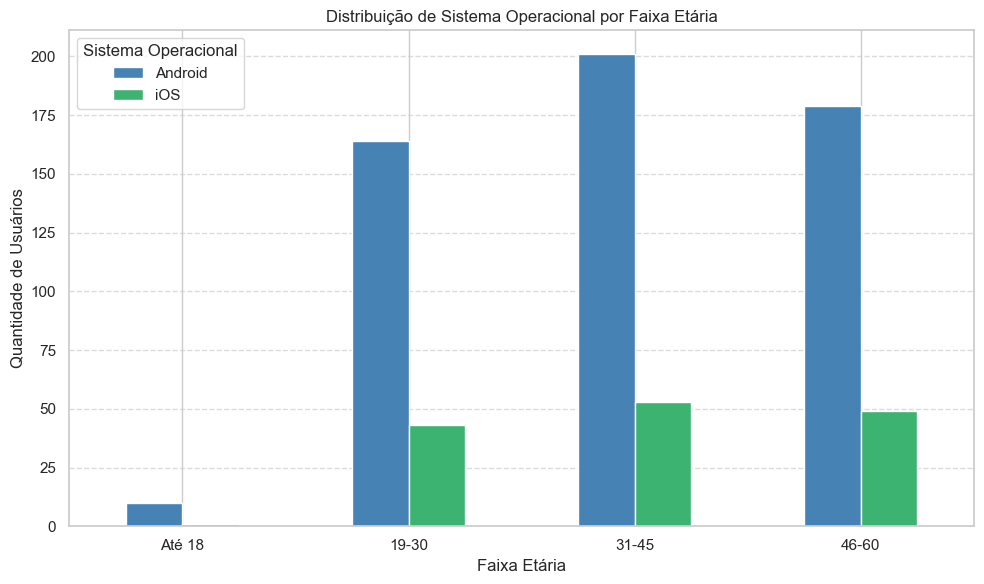

In [19]:
# Criando as mesmas faixas etárias utilizadas anteriormente
bins = [0, 18, 30, 45, 60, 100]
labels = ['Até 18', '19-30', '31-45', '46-60', 'Acima de 60']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

# Agrupando por faixa etária e sistema operacional
os_age_dist = df.groupby(['Age Group', 'Operating System'], observed=True).size().unstack(fill_value=0)

print("Distribuição de Sistema Operacional por Faixa Etária:")
print(os_age_dist)

# Criando a visualização
plt.figure(figsize=(10, 6))
os_age_dist.plot(kind='bar', stacked=False, figsize=(10,6), color=['#4682B4', '#3CB371'])
plt.title('Distribuição de Sistema Operacional por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Quantidade de Usuários')
plt.xticks(rotation=0)
plt.legend(title='Sistema Operacional')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('os_por_idade.png')
plt.show()

## 10 Classes de comportamento 

Médias por Classe de Comportamento:
   User Behavior Class  App Usage Time (min/day)  Screen On Time (hours/day)  \
0                    1                 60.426471                    1.490441   
1                    2                131.972603                    3.037671   
2                    3                235.398601                    4.955944   
3                    4                395.748201                    6.909353   
4                    5                541.419118                   10.114706   

         Age  
0  38.213235  
1  38.643836  
2  38.678322  
3  38.676259  
4  38.176471  

Distribuição de Gênero (%) por Classe:
Gender                  Female       Male
User Behavior Class                      
1                    46.323529  53.676471
2                    43.835616  56.164384
3                    57.342657  42.657343
4                    48.201439  51.798561
5                    44.117647  55.882353


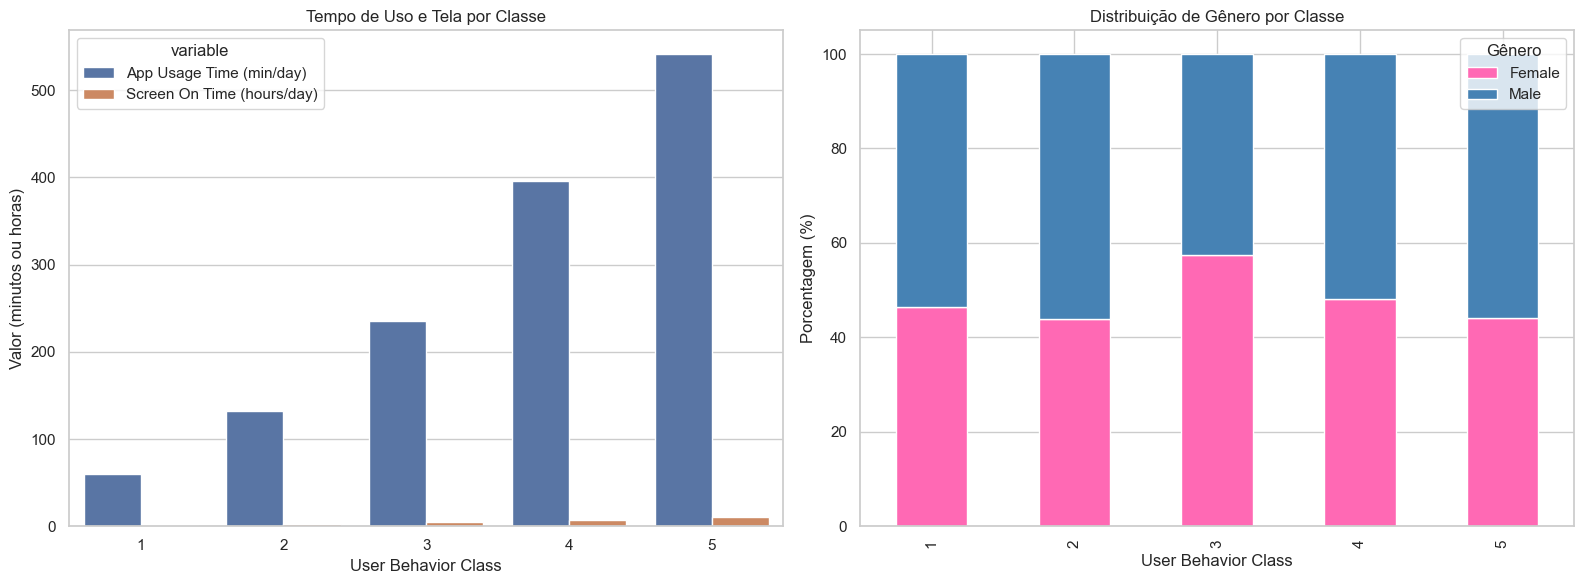

In [20]:
# 1. Média de métricas por Classe de Comportamento
metrics_by_class = df.groupby('User Behavior Class').agg({
    'App Usage Time (min/day)': 'mean',
    'Screen On Time (hours/day)': 'mean',
    'Age': 'mean'
}).reset_index()

print("Médias por Classe de Comportamento:")
print(metrics_by_class)

# 2. Distribuição de Gênero por Classe
gender_dist = pd.crosstab(df['User Behavior Class'], df['Gender'], normalize='index') * 100

print("\nDistribuição de Gênero (%) por Classe:")
print(gender_dist)

# Visualização das métricas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de Tempo de Uso e Tempo de Tela (Escalas diferentes, usaremos dois eixos se necessário, ou barras separadas)
metrics_melted = metrics_by_class.melt(id_vars='User Behavior Class', value_vars=['App Usage Time (min/day)', 'Screen On Time (hours/day)'])
sns.barplot(data=metrics_melted, x='User Behavior Class', y='value', hue='variable', ax=axes[0])
axes[0].set_title('Tempo de Uso e Tela por Classe')
axes[0].set_ylabel('Valor (minutos ou horas)')

# Gráfico de Gênero
gender_dist.plot(kind='bar', stacked=True, ax=axes[1], color=['#FF69B4', '#4682B4'])
axes[1].set_title('Distribuição de Gênero por Classe')
axes[1].set_ylabel('Porcentagem (%)')
axes[1].legend(title='Gênero', loc='upper right')

plt.tight_layout()
plt.savefig('analise_comportamento.png')
plt.show()